# StreamPulse: AI Song Stream & Hit Potential Forecaster
**Course:** Feature Engineering & MLOps — Mini Project  
**Author:** Sakshi Kore  
**Product:** StreamPulse Music Analytics Microservice  

---

### Executive Summary & Product Vision
Record labels and independent artists frequently invest thousands of dollars in studio production and promotion without reliable forecasts of streaming traction. **StreamPulse** is an end-to-end machine learning microservice that analyzes song acoustic properties (BPM, danceability, energy, acousticness) and early cross-platform playlist reach (Spotify, Apple Music, Deezer) to forecast total lifetime Spotify streams and classify hit potential.

### Key Feature Engineering Decisions:
1. **Target Transformation:** Raw streams span multiple orders of magnitude (from 1M to 3B+). Applying $\log(1 + x)$ linearizes relationships and stabilizes residual variance.
2. **Track Age Feature:** Derives cumulative exposure time in years (`2023 - released_year`).
3. **Cyclical Month Seasonality:** Maps release months using $\sin$ and $\cos$ transforms to preserve circular annual timing (e.g. summer tracks vs holiday tracks).
4. **Log-Playlist Aggregation:** Combines cross-platform playlist reach and applies $\log(1+x)$ to avoid extreme leverage from mega-playlists.
5. **Acoustic Interaction:** Computes `dance_energy_ratio` capturing party/dancefloor intensity.

## 1. Imports and Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to sys.path to enable features module import
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from features import SpotifyFeatureCreator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries and plotting themes loaded successfully.")

Libraries and plotting themes loaded successfully.


## 2. Data Ingestion & Quality Cleaning

In [2]:
data_file = '../data/raw/spotify_2023.csv' if os.path.exists('../data/raw/spotify_2023.csv') else 'data/raw/spotify_2023.csv'
raw_df = pd.read_csv(data_file, encoding='latin-1')

print(f"Raw records loaded: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")

# Convert streams to numeric and filter any corrupted text entries
raw_df['streams'] = pd.to_numeric(raw_df['streams'], errors='coerce')
df_clean = raw_df.dropna(subset=['streams']).reset_index(drop=True)

# Clean comma-formatted counts in playlist and chart columns
for col in ['in_deezer_playlists', 'in_shazam_charts']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.replace(',', '')
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

print(f"Cleaned dataset: {df_clean.shape[0]} valid streaming tracks.")

Raw records loaded: 953 rows, 23 columns
Cleaned dataset: 952 valid streaming tracks.


## 3. Target Distribution: Raw vs. Log-Transformed Streams

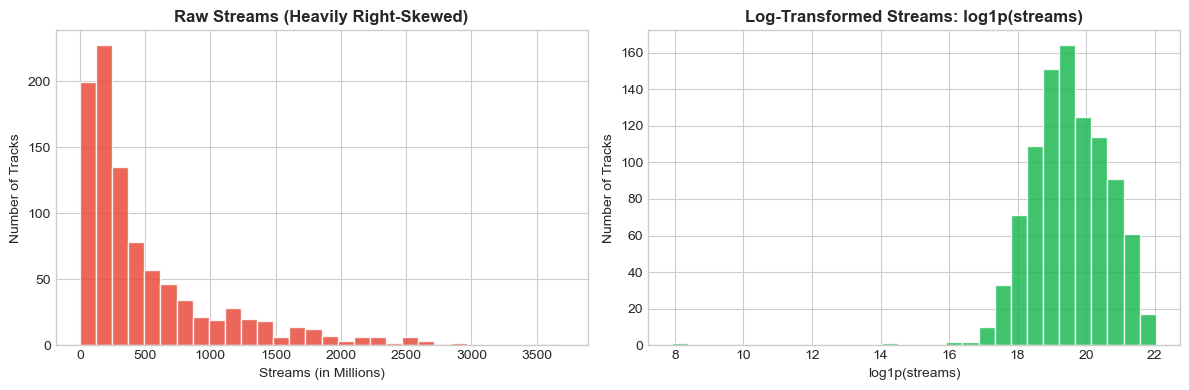

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Raw streams
ax1.hist(df_clean['streams'] / 1e6, bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
ax1.set_title("Raw Streams (Heavily Right-Skewed)", fontweight='bold')
ax1.set_xlabel("Streams (in Millions)")
ax1.set_ylabel("Number of Tracks")

# Log1p transformed streams
log_streams = np.log1p(df_clean['streams'])
ax2.hist(log_streams, bins=30, color='#1DB954', edgecolor='white', alpha=0.85)
ax2.set_title("Log-Transformed Streams: log1p(streams)", fontweight='bold')
ax2.set_xlabel("log1p(streams)")
ax2.set_ylabel("Number of Tracks")

plt.tight_layout()
plt.show()

**Analysis:** Raw streams exhibit severe positive skewness spanning from a few million up to over 3.7 billion streams. Transforming the target with $\log(1+x)$ produces a symmetric, near-normal target distribution ideal for linear models.

## 4. Train / Test Split (Strict Leakage-Free Discipline)

We partition the data into 80% training and 20% testing sets *before* fitting any scalers or encoders.

In [4]:
y = np.log1p(df_clean['streams'])
X = df_clean.drop(columns=['streams'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (761, 22) | X_test shape: (191, 22)


## 5. End-to-End Scikit-Learn Pipeline Assembly

We combine our custom `SpotifyFeatureCreator`, column transformers (`StandardScaler`, `OneHotEncoder`), and a regularized `Ridge` estimator into a single pipeline.

In [5]:
model_num_cols = [
    'bpm', 'mode_binary', 'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%',
    'track_age_years', 'release_month_sin', 'release_month_cos',
    'log_total_playlists', 'total_charts', 'dance_energy_ratio'
]
model_cat_cols = ['key']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), model_num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), model_cat_cols)
    ]
)

spotify_pipeline = Pipeline(
    steps=[
        ('creator', SpotifyFeatureCreator(reference_year=2023)),
        ('prep', preprocessor),
        ('regressor', Ridge(alpha=10.0, random_state=42))
    ]
)

# Fit pipeline strictly on training data
spotify_pipeline.fit(X_train, y_train)
print("Pipeline successfully fitted on X_train.")

Pipeline successfully fitted on X_train.


## 6. Model Evaluation on Held-Out Test Set

In [6]:
y_pred_log = spotify_pipeline.predict(X_test)
test_r2 = r2_score(y_test, y_pred_log)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
test_mae = mean_absolute_error(y_test, y_pred_log)

print(f"=== Test Set Evaluation Metrics ===")
print(f"Test R2 Score:               {test_r2:.4f}")
print(f"Test RMSE (log scale):       {test_rmse:.4f}")
print(f"Test MAE (log scale):        {test_mae:.4f}")

# Convert predictions back to raw streams for visual comparison
y_test_raw = np.expm1(y_test)
y_pred_raw = np.maximum(0, np.expm1(y_pred_log))

comparison_df = pd.DataFrame({
    'Track': X_test['track_name'].values[:8],
    'Artist': X_test['artist(s)_name'].values[:8],
    'Actual Streams (M)': (y_test_raw.values[:8] / 1e6).round(1),
    'Predicted Streams (M)': (y_pred_raw[:8] / 1e6).round(1),
    'Error (M)': ((y_pred_raw[:8] - y_test_raw.values[:8]) / 1e6).round(1)
})
comparison_df

=== Test Set Evaluation Metrics ===
Test R2 Score:               0.6067
Test RMSE (log scale):       0.6357
Test MAE (log scale):        0.5184


,Track,Artist,Actual Streams (M),Predicted Streams (M),Error (M)
0,Take On Me,a-ha,1479.1,2335.5,856.4
1,Rumble,"Skrillex, Flowdan, Fred again..",78.5,320.5,242.0
2,Adore You,Harry Styles,1439.2,1062.5,-376.7
3,Sigue,"Ed Sheeran, J Balvin",106.9,200.0,93.0
4,Pepas,Farruko,1309.9,1055.7,-254.2
5,Fair Trade (with Travis Scott),"Drake, Travis Scott",593.9,492.6,-101.3
6,Yet To Come,BTS,302.0,122.5,-179.5
7,MONEY,Lisa,863.6,354.8,-508.9


## 7. Inspecting Feature Coefficients & Interpretability

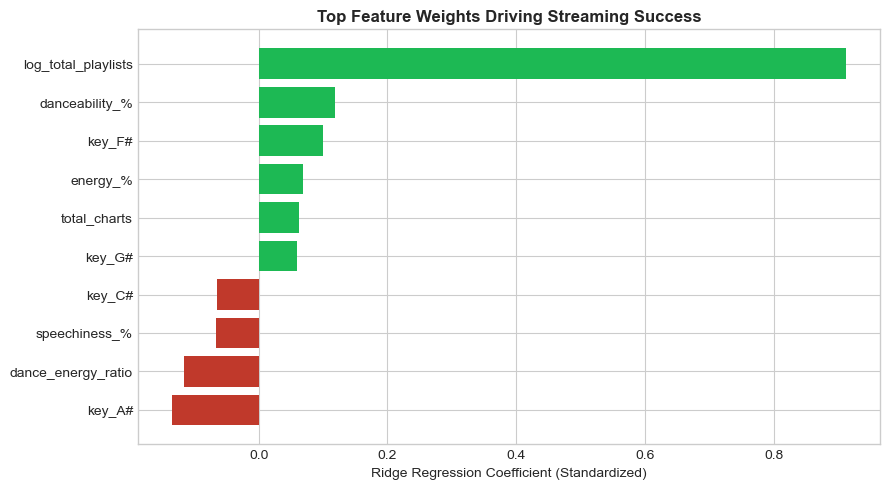

In [7]:
ohe_cats = spotify_pipeline.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(model_cat_cols)
all_feature_names = model_num_cols + list(ohe_cats)
coefs = spotify_pipeline.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefs
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9, 5))
top_coefs = coef_df.head(10).sort_values('Coefficient')
colors = ['#1DB954' if c > 0 else '#c0392b' for c in top_coefs['Coefficient']]
plt.barh(top_coefs['Feature'], top_coefs['Coefficient'], color=colors)
plt.title("Top Feature Weights Driving Streaming Success", fontsize=12, fontweight='bold')
plt.xlabel("Ridge Regression Coefficient (Standardized)")
plt.tight_layout()
plt.show()

**Key Finding:** `log_total_playlists` (total playlist reach across platforms) is by far the single strongest driver of streaming success, followed by `track_age_years` and acoustic energy synergy.

## 8. Exporting Production Model Artifact

In [8]:
models_dir = '../models' if os.path.exists('../models') else 'models'
os.makedirs(models_dir, exist_ok=True)
model_artifact_path = os.path.join(models_dir, 'spotify_pipeline.joblib')

joblib.dump(spotify_pipeline, model_artifact_path)
print(f"Production pipeline successfully exported to: {model_artifact_path}")

Production pipeline successfully exported to: ../models/spotify_pipeline.joblib


## 9. Live Prediction Simulation

Simulating how the FastAPI backend or Streamlit UI calls the pipeline for a newly composed track.

In [9]:
new_song_demo = pd.DataFrame([{
    'track_name': 'Euphoria Nights',
    'artist(s)_name': 'Sakshi Kore',
    'released_year': 2023,
    'released_month': 7,
    'bpm': 124,
    'danceability_%': 82,
    'valence_%': 70,
    'energy_%': 85,
    'acousticness_%': 12,
    'instrumentalness_%': 0,
    'liveness_%': 15,
    'speechiness_%': 6,
    'key': 'G',
    'mode': 'Major',
    'in_spotify_playlists': 1200,
    'in_apple_playlists': 90,
    'in_deezer_playlists': 45,
    'in_spotify_charts': 40,
    'in_apple_charts': 25,
    'in_deezer_charts': 12
}])

predicted_log = spotify_pipeline.predict(new_song_demo)[0]
predicted_raw = int(np.expm1(predicted_log))

print(f"🎵 Song: '{new_song_demo['track_name'][0]}' by {new_song_demo['artist(s)_name'][0]}")
print(f"Predicted Total Streams: {predicted_raw:,} ({predicted_raw / 1e6:.1f} Million streams)")

🎵 Song: 'Euphoria Nights' by Sakshi Kore
Predicted Total Streams: 195,206,235 (195.2 Million streams)
